ENSF 444 Project

Crime Count

Group 28

Team Members:

Ali Awan ()

Ali Chaudhary (30204228)

Tyseer Ammar Shahriar()

# ENSF 444 Project: Calgary Crime Prediction

## Problem Description
The goal of this project is to help the Calgary Police Service predict the number of crimes that may occur in different communities based on historical crime data.

By using machine learning models, we aim to identify patterns in crime occurrences using features such as location, time, and crime category. This can help improve resource allocation and proactive policing strategies.

## Objective
We will compare three machine learning models:
- Random Forest (non-linear)
- Gradient Boosting (non-linear)
- Lasso Regression (linear)

The goal is to determine which model performs best for predicting crime counts.

In [10]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mglearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1.) Data Loading

In [12]:
#Load dataset (make sure file is in same folder or adjust path)
df = pd.read_csv("data/Community_Crime_Statistics_20240102.csv")

#Standardize column names (lowercase and replace spaces with underscores)
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("Dataset loaded successfully. Shape:", df.shape)
# Preview data for first few rows
df.head()


Dataset loaded successfully. Shape: (66349, 10)


,sector,community_name,category,crime_count,resident_count,date,year,month,id,community_center_point
0,NORTHWEST,01B,Assault (Non-domestic),1,0.0,2022/11,2022,NOV,2022-NOV-01B-Assault (Non-domestic),POINT (-114.24261426059833 51.102826007628536)
1,NORTHWEST,01B,Break & Enter - Commercial,1,0.0,2019/06,2019,JUN,2019-JUN-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)
2,NORTHWEST,01B,Break & Enter - Commercial,1,0.0,2019/08,2019,AUG,2019-AUG-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)
3,NORTHWEST,01B,Break & Enter - Commercial,2,0.0,2020/03,2020,MAR,2020-MAR-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)
4,NORTHWEST,01B,Break & Enter - Commercial,2,0.0,2020/07,2020,JUL,2020-JUL-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)


# 2.) Data Cleaning

In [3]:

print("Dataset Shape (Before):", df.shape)
print("\nMissing values BEFORE cleaning:")
print(df.isnull().sum())

df.info()

# Drop missing values
df = df.dropna()

print("\nDataset Shape (After):", df.shape)
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

Dataset Shape (Before): (66349, 10)

Missing values BEFORE cleaning:
sector                    30
community_name             0
category                   0
crime_count                0
resident_count            67
date                       0
year                       0
month                      0
id                         0
community_center_point    30
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 66349 entries, 0 to 66348
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sector                  66319 non-null  str    
 1   community_name          66349 non-null  str    
 2   category                66349 non-null  str    
 3   crime_count             66349 non-null  int64  
 4   resident_count          66282 non-null  float64
 5   date                    66349 non-null  str    
 6   year                    66349 non-null  int64  
 7   month                   66349 non-null  str    


# 3.) Feature Selection

In [7]:
# Target variable
target = "crime_count"

# Selected features (only using features that we know before the prediction is made)
features = ["sector", "community_name", "year", "month", "resident_count"]

X = df[features]
y = df[target]

In [8]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)


# 4.) Model 1 - Random Forest


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Define feature types

# Categorical features (text-based → need encoding)
categorical_features = ["sector", "community_name", "month"]

# Numerical features (already numeric)
numerical_features = ["year", "resident_count"]



# Preprocessing step

# ColumnTransformer applies different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        # Convert categorical variables into numerical format using One-Hot Encoding
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        
        # Keep numerical features as they are (no scaling needed for Random Forest)
        ("num", "passthrough", numerical_features)
    ]
)



# Build the full pipeline

# Pipeline ensures preprocessing and model training happen together consistently
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),  # Step 1: transform input data
    
    ("model", RandomForestRegressor(
        n_estimators=300,       # Number of trees (more trees = more stable predictions)
        max_depth=10,           # Limits tree depth to prevent overfitting
        min_samples_leaf=5,     # Minimum samples in a leaf → smoother predictions
        max_features="sqrt",    # Random subset of features at each split → increases diversity
        random_state=42         # Ensures reproducibility of results
    ))
])




# Fit the pipeline on training data:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

# 5.) Predictions and Scores

Mean Squared Error (MSE): 10.39
Root Mean Squared Error (RMSE): 3.22
Mean Absolute Error (MAE): 1.92
R^2 Score: 0.16


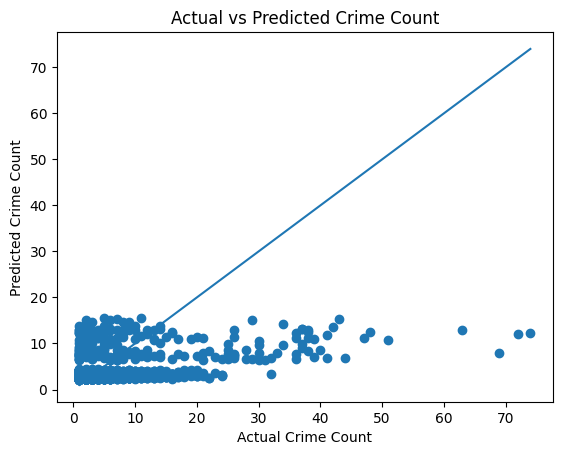

In [ ]:

# Make predictions
y_pred = rf_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R^2 Score: {r2:.2f}")

# Plot: Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Actual vs Predicted Crime Count")

#add perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

We applied a Random Forest regression model to predict crime counts using historical data based on features such as location (sector and community) and temporal variables (year and month), along with population information (resident_count). Categorical features were transformed using One-Hot Encoding to convert them into a numerical format suitable for the model. A pipeline and column transformer were used to ensure consistent preprocessing and proper handling of different feature types. The dataset was split into training and testing sets, allowing the model to learn patterns from past data and be evaluated on unseen data.

The Random Forest model works by constructing multiple decision trees using random subsets of the data and features, and then averaging their predictions to produce a final output.

The model achieved a Mean Squared Error of approximately 10.39, a Root Mean Squared Error of 3.22, a Mean Absolute Error of 1.92, and an R² score of 0.16. While this shows some improvement over a baseline model, the relatively low R² value indicates that the model explains only a small portion of the variability in crime counts. The prediction vs. actual plot further shows that the model tends to underestimate higher crime values and is biased toward predicting values near the average.

This suggests that the selected features were still not sufficient to capture the underlying patterns in the data. Although the dataset contains multiple columns, many were either not suitable for prediction or could introduce data leakage, such as the crime category. As a result, the model relied primarily on basic spatial and temporal features. However, crime patterns are influenced by additional factors such as historical trends, socioeconomic conditions, and population dynamics. In particular, the lack of historical features (previous crime counts) likely limited the model’s ability to capture temporal dependencies, leading to a worse predictive system. 